In [11]:
# Importing Libraries

# Data Processing
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing and Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,mean_squared_error,
    mean_absolute_error,
    classification_report,
    confusion_matrix,
)

# Deep Learning: TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Model and Preprocessor Saving
import joblib

In [12]:
# Load and Inspect the Datasets

# Load the Books, Ratings, and Users datasets
books_df = pd.read_csv("Books.csv")
ratings_df = pd.read_csv("Ratings.csv")
users_df = pd.read_csv("Users.csv")

# Books Dataset Overview
print("BOOKS DATASET")
display(books_df.head())

print(f"Shape: {books_df.shape}")
print("\nColumn Names:")
print(books_df.columns.tolist())

print("\nData Types:")
print(books_df.dtypes)

print("\nMissing Values:")
print(books_df.isnull().sum())

# Ratings Dataset Overview
print("\n" + "=" * 60)
print("RATINGS DATASET")
display(ratings_df.head())

print(f"Shape: {ratings_df.shape}")
print("\nColumn Names:")
print(ratings_df.columns.tolist())

print("\nData Types:")
print(ratings_df.dtypes)

print("\nMissing Values:")
print(ratings_df.isnull().sum())

# Users Dataset Overview
print("\n" + "=" * 60)
print("USERS DATASET")
display(users_df.head())

print(f"Shape: {users_df.shape}")
print("\nColumn Names:")
print(users_df.columns.tolist())

print("\nData Types:")
print(users_df.dtypes)

print("\nMissing Values:")
print(users_df.isnull().sum())

/tmp/ipykernel_2343/1238931529.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books_df = pd.read_csv("Books.csv")


BOOKS DATASET


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


Shape: (271360, 8)

Column Names:
['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']

Data Types:
ISBN                   object
Book-Title             object
Book-Author            object
Year-Of-Publication    object
Publisher              object
Image-URL-S            object
Image-URL-M            object
Image-URL-L            object
dtype: object

Missing Values:
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

RATINGS DATASET


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


Shape: (1149780, 3)

Column Names:
['User-ID', 'ISBN', 'Book-Rating']

Data Types:
User-ID         int64
ISBN           object
Book-Rating     int64
dtype: object

Missing Values:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

USERS DATASET


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


Shape: (278858, 3)

Column Names:
['User-ID', 'Location', 'Age']

Data Types:
User-ID       int64
Location     object
Age         float64
dtype: object

Missing Values:
User-ID          0
Location         0
Age         110762
dtype: int64


BOOKS DATASET SUMMARY


,count,unique,top,freq
ISBN,271360,271360,020130998X,1
Book-Title,271360,242135,Selected Poems,27
Book-Author,271358,102022,Agatha Christie,632
Year-Of-Publication,271360,202,2002,13903
Publisher,271358,16807,Harlequin,7535
Image-URL-S,271360,271044,http://images.amazon.com/images/P/042509474X.0...,2
Image-URL-M,271360,271044,http://images.amazon.com/images/P/042509474X.0...,2
Image-URL-L,271357,271041,http://images.amazon.com/images/P/006091985X.0...,2



RATINGS DATASET SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User-ID,1149780.0,NaN,NaN,NaN,140386.395126,80562.277718,2.0,70345.0,141010.0,211028.0,278854.0
ISBN,1149780,340556,0971880107,2502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Book-Rating,1149780.0,NaN,NaN,NaN,2.86695,3.854184,0.0,0.0,0.0,7.0,10.0



USERS DATASET SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User-ID,278858.0,NaN,NaN,NaN,139429.5,80499.51502,1.0,69715.25,139429.5,209143.75,278858.0
Location,278858,57339,"london, england, united kingdom",2506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,168096.0,NaN,NaN,NaN,34.751434,14.428097,0.0,24.0,32.0,44.0,244.0


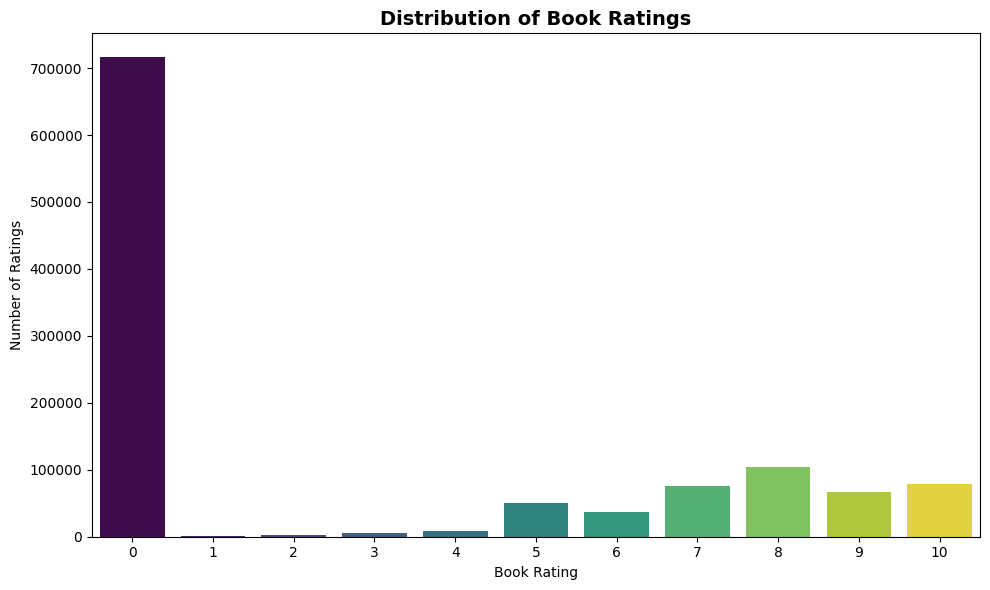

Top-Rated Books:


,Book-Title,Average_Rating,Rating_Count
0,Postmarked Yesteryear: 30 Rare Holiday Postcards,10.000000,11
1,Dilbert: A Book of Postcards,9.923077,13
2,Harry Potter and the Chamber of Secrets Postca...,9.869565,23
3,The Lorax,9.800000,10
4,Kiss of the Night (A Dark-Hunter Novel),9.800000,10
5,Route 66 Postcards: Greetings from the Mother ...,9.727273,11
6,Maus 1. Mein Vater kotzt Geschichte aus. Die G...,9.700000,10
7,Ranma 1/2 (Ranma 1/2),9.700000,10
8,"The Return of the King (The Lord of The Rings,...",9.625000,16
9,Harry Potter Und Der Feuerkelch,9.600000,10


/tmp/ipykernel_2343/3224859331.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


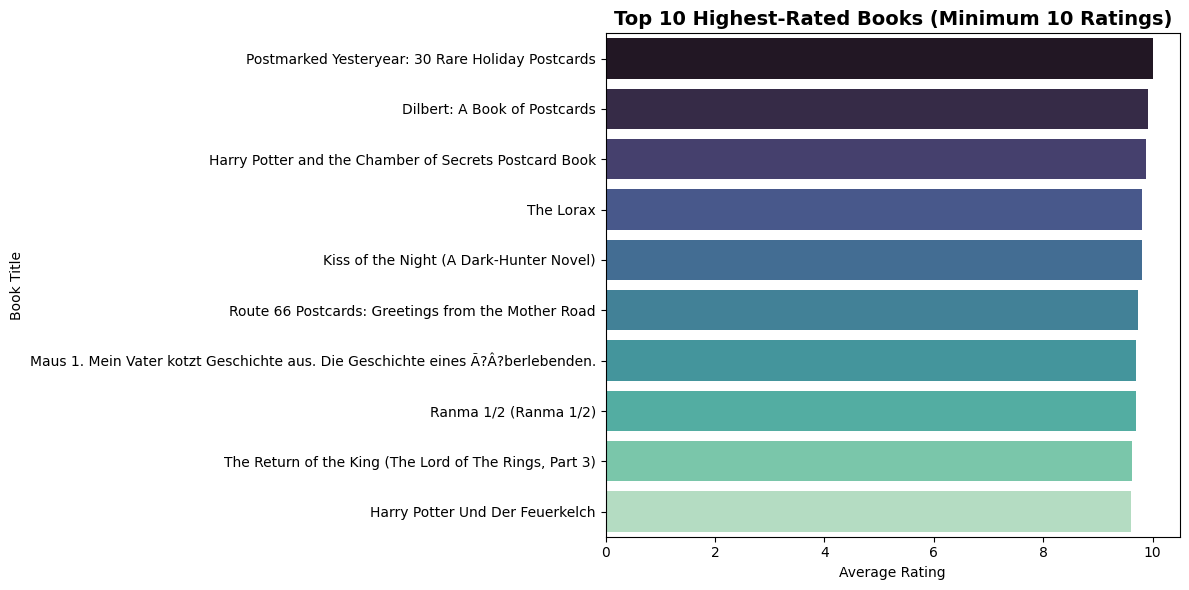

Most-Rated Books:


,Book-Title,Rating_Count
0,Wild Animus,2502
1,The Lovely Bones: A Novel,1295
2,The Da Vinci Code,898
3,A Painted House,838
4,The Nanny Diaries: A Novel,828
5,Bridget Jones's Diary,815
6,The Secret Life of Bees,774
7,Divine Secrets of the Ya-Ya Sisterhood: A Novel,740
8,The Red Tent (Bestselling Backlist),723
9,Angels &amp; Demons,670


/tmp/ipykernel_2343/3224859331.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


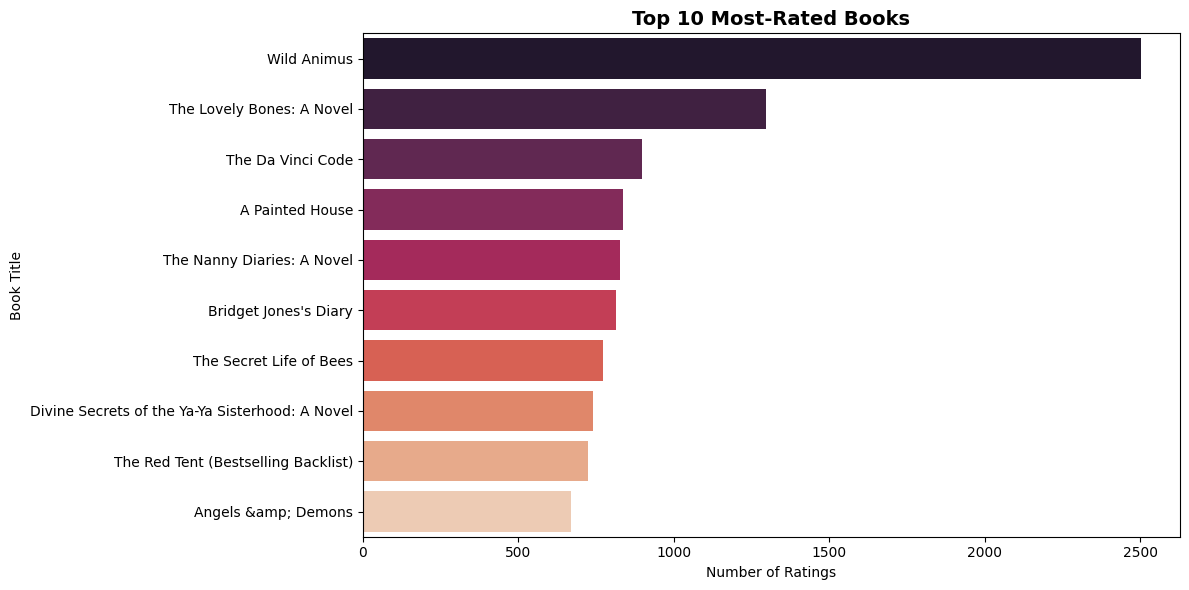

/tmp/ipykernel_2343/3224859331.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


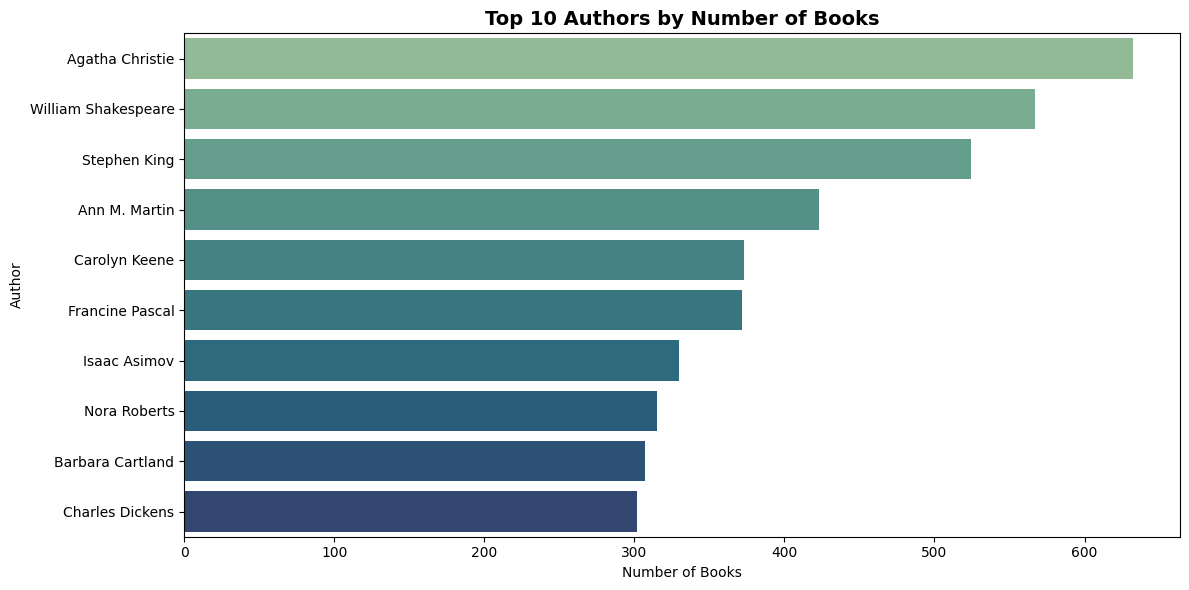

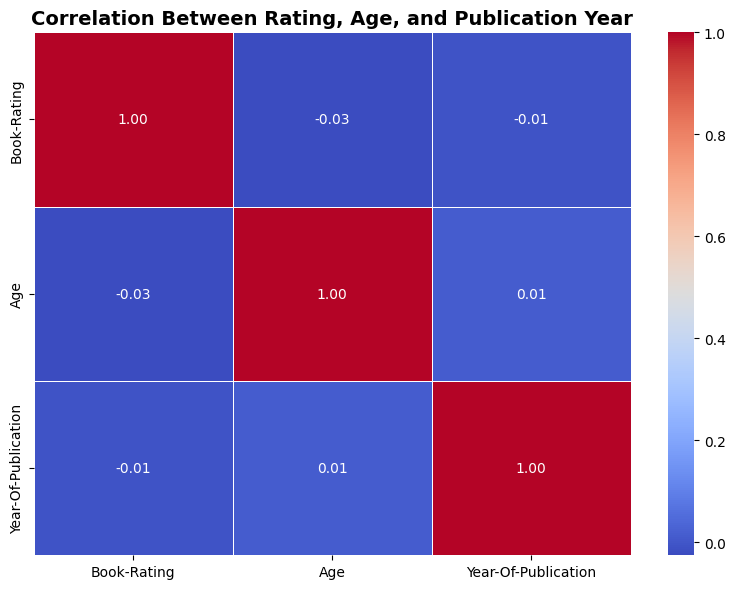

In [14]:
# Exploratory Data Analysis (EDA)

# Summary Statistics
# Review descriptive statistics for all three datasets.
print("BOOKS DATASET SUMMARY")
display(books_df.describe(include="all").T)

print("\nRATINGS DATASET SUMMARY")
display(ratings_df.describe(include="all").T)

print("\nUSERS DATASET SUMMARY")
display(users_df.describe(include="all").T)

# ------------------------------------------------------------
# Rating Distribution
# This chart shows the frequency of each book rating provided by users.
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.countplot(
    data=ratings_df,
    x="Book-Rating",
    hue="Book-Rating",
    palette="viridis",
    legend=False
)
plt.title("Distribution of Book Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Book Rating")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Merge Books and Ratings for Book-Level Analysis
# This temporary dataset is used only for EDA and does not alter
# the original datasets.
# ------------------------------------------------------------
book_ratings_eda = ratings_df.merge(
    books_df[["ISBN", "Book-Title", "Book-Author"]],
    on="ISBN",
    how="inner"
)

# ------------------------------------------------------------
# Top-Rated Books
# Books need at least 10 ratings to avoid highlighting books with
# a high rating based on very few user ratings.
# ------------------------------------------------------------
book_rating_summary = (
    book_ratings_eda[book_ratings_eda["Book-Rating"] > 0]
    .groupby("Book-Title")["Book-Rating"]
    .agg(Average_Rating="mean", Rating_Count="count")
    .query("Rating_Count >= 10")
    .sort_values("Average_Rating", ascending=False)
    .head(10)
    .reset_index()
)

print("Top-Rated Books:")
display(book_rating_summary)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=book_rating_summary,
    x="Average_Rating",
    y="Book-Title",
    palette="mako"
)
plt.title("Top 10 Highest-Rated Books (Minimum 10 Ratings)", fontsize=14, fontweight="bold")
plt.xlabel("Average Rating")
plt.ylabel("Book Title")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Most-Rated Books
# This chart identifies books that have received the most ratings.
# ------------------------------------------------------------
most_rated_books = (
    book_ratings_eda.groupby("Book-Title")["Book-Rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="Rating_Count")
)

print("Most-Rated Books:")
display(most_rated_books)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=most_rated_books,
    x="Rating_Count",
    y="Book-Title",
    palette="rocket"
)
plt.title("Top 10 Most-Rated Books", fontsize=14, fontweight="bold")
plt.xlabel("Number of Ratings")
plt.ylabel("Book Title")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Author Distribution
# This chart shows authors with the largest number of books listed.
# ------------------------------------------------------------
top_authors = (
    books_df["Book-Author"]
    .value_counts()
    .head(10)
    .reset_index()
)
top_authors.columns = ["Book-Author", "Book_Count"]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_authors,
    x="Book_Count",
    y="Book-Author",
    palette="crest"
)
plt.title("Top 10 Authors by Number of Books", fontsize=14, fontweight="bold")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Correlation Analysis
# ------------------------------------------------------------
eda_correlation_df = (
    ratings_df
    .merge(users_df[["User-ID", "Age"]], on="User-ID", how="inner")
    .merge(books_df[["ISBN", "Year-Of-Publication"]], on="ISBN", how="inner")
)

# Convert columns to numeric
eda_correlation_df["Age"] = pd.to_numeric(
    eda_correlation_df["Age"],
    errors="coerce"
)

eda_correlation_df["Year-Of-Publication"] = pd.to_numeric(
    eda_correlation_df["Year-Of-Publication"],
    errors="coerce"
)

eda_correlation_df["Book-Rating"] = pd.to_numeric(
    eda_correlation_df["Book-Rating"],
    errors="coerce"
)

# Keep only numeric columns
correlation_columns = [
    "Book-Rating",
    "Age",
    "Year-Of-Publication"
]

correlation_data = (
    eda_correlation_df[correlation_columns]
    .dropna()
)

# Plot Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Between Rating, Age, and Publication Year",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [15]:
# Merge Datasets

# ------------------------------------------------------------
# Merge Ratings with Books using ISBN
# Each rating is matched with its corresponding book details.
# ------------------------------------------------------------
ratings_books_df = ratings_df.merge(
    books_df,
    on="ISBN",
    how="inner"
)

# ------------------------------------------------------------
# Merge User Details using User-ID
# Each book rating is matched with the corresponding user information.
# ------------------------------------------------------------
merged_df = ratings_books_df.merge(
    users_df,
    on="User-ID",
    how="inner"
)

# Display merged dataset shape
print(f"Merged Dataset Shape: {merged_df.shape}")

# Display the first five rows of the merged dataset
display(merged_df.head())

# ------------------------------------------------------------
# Verify Merge Success
# Confirm that key fields from all three datasets are present and
# check whether any unmatched values remain in the merged dataset.
# ------------------------------------------------------------
required_columns = [
    "User-ID",
    "ISBN",
    "Book-Title",
    "Book-Author",
    "Book-Rating",
    "Location",
    "Age"
]

print("\nMerge Verification:")
print(f"All required columns present: {set(required_columns).issubset(merged_df.columns)}")

print("\nMissing Values in Merge Keys:")
print(merged_df[["User-ID", "ISBN"]].isnull().sum())

print(f"\nTotal Merged Records: {len(merged_df):,}")

Merged Dataset Shape: (1031136, 12)


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa",NaN
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa",NaN
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,"h, new south wales, australia",16.0
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,"rijeka, n/a, croatia",16.0
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,"rijeka, n/a, croatia",16.0



Merge Verification:
All required columns present: True

Missing Values in Merge Keys:
User-ID    0
ISBN       0
dtype: int64

Total Merged Records: 1,031,136


In [17]:
ratings_books_df["Book-Rating"].value_counts().sort_index()


,count
Book-Rating,
0,647294
1,1481
2,2375
3,5118
4,7617
5,45355
6,31687
7,66402
8,91804


In [18]:
# Data Cleaning

# Create a copy of the merged dataset to preserve the original merged data
cleaned_df = merged_df.copy()

# ------------------------------------------------------------
# Remove Duplicate Rows
# Duplicate user-book rating records can bias model training.
# ------------------------------------------------------------
cleaned_df = cleaned_df.drop_duplicates()

# ------------------------------------------------------------
# Keep Only Useful Columns
# Retain identifiers, book details, user information, and ratings
# required for building the recommendation system.
# ------------------------------------------------------------
useful_columns = [
    "User-ID",
    "ISBN",
    "Book-Title",
    "Book-Author",
    "Year-Of-Publication",
    "Publisher",
    "Book-Rating",
    "Location",
    "Age"
]

cleaned_df = cleaned_df[
    [column for column in useful_columns if column in cleaned_df.columns]
].copy()

# ------------------------------------------------------------
# Handle Missing Essential Book Information
# Remove records without ISBN, title, author, or user ID because these
# fields are essential for linking users, books, and ratings.
# ------------------------------------------------------------
essential_columns = ["User-ID", "ISBN", "Book-Title", "Book-Author", "Book-Rating"]

cleaned_df = cleaned_df.dropna(
    subset=[column for column in essential_columns if column in cleaned_df.columns]
)

# ------------------------------------------------------------
# Handle Missing Optional Book and User Information
# Fill missing publisher and location values with "Unknown" because
# they are descriptive fields rather than model targets.
# ------------------------------------------------------------
for column in ["Publisher", "Location"]:
    if column in cleaned_df.columns:
        cleaned_df[column] = cleaned_df[column].fillna("Unknown")

# ------------------------------------------------------------
# Handle Invalid or Missing Ages
# Valid ages are assumed to be between 5 and 100. Invalid values are
# converted to missing values and then filled with the median valid age.
# ------------------------------------------------------------
if "Age" in cleaned_df.columns:
    cleaned_df.loc[
        (cleaned_df["Age"] < 5) | (cleaned_df["Age"] > 100),
        "Age"
    ] = np.nan

    cleaned_df["Age"] = cleaned_df["Age"].fillna(cleaned_df["Age"].median())

# ------------------------------------------------------------
# Handle Invalid Publication Years
# Keep realistic publication years and replace invalid values with
# the median valid publication year.
# ------------------------------------------------------------
if "Year-Of-Publication" in cleaned_df.columns:
    cleaned_df["Year-Of-Publication"] = pd.to_numeric(
        cleaned_df["Year-Of-Publication"],
        errors="coerce"
    )

    cleaned_df.loc[
        (cleaned_df["Year-Of-Publication"] < 1000)
        | (cleaned_df["Year-Of-Publication"] > 2026),
        "Year-Of-Publication"
    ] = np.nan

    cleaned_df["Year-Of-Publication"] = cleaned_df["Year-Of-Publication"].fillna(
        cleaned_df["Year-Of-Publication"].median()
    )

# ------------------------------------------------------------
# Remove Implicit Ratings
# In the Book-Crossing dataset, a rating of 0 indicates that the
# user did not explicitly rate the book. These records are removed
# so that the model learns only from actual user preferences.
# ------------------------------------------------------------
if "Book-Rating" in cleaned_df.columns:
    cleaned_df = cleaned_df[cleaned_df["Book-Rating"] > 0]

# ------------------------------------------------------------
# Keep Active Users
# Retain users who have rated at least 20 books to reduce data
# sparsity and improve recommendation quality.
# ------------------------------------------------------------
user_rating_counts = cleaned_df["User-ID"].value_counts()
active_users = user_rating_counts[user_rating_counts >= 20].index

cleaned_df = cleaned_df[
    cleaned_df["User-ID"].isin(active_users)
]

# ------------------------------------------------------------
# Keep Popular Books
# Retain books that have received at least 20 ratings.
# This removes very rarely rated books and improves model learning.
# ------------------------------------------------------------
book_rating_counts = cleaned_df["ISBN"].value_counts()
popular_books = book_rating_counts[book_rating_counts >= 20].index

cleaned_df = cleaned_df[
    cleaned_df["ISBN"].isin(popular_books)
]

# ------------------------------------------------------------
# Reset the Index
# Resetting ensures a clean, continuous index after row removals.
# ------------------------------------------------------------
cleaned_df = cleaned_df.reset_index(drop=True)

# Display the cleaned dataset and remaining missing values
print(f"Cleaned Dataset Shape: {cleaned_df.shape}")

print("\nRemaining Missing Values:")
print(cleaned_df.isnull().sum())

display(cleaned_df.head())

Cleaned Dataset Shape: (28821, 9)

Remaining Missing Values:
User-ID                0
ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Book-Rating            0
Location               0
Age                    0
dtype: int64


,User-ID,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Book-Rating,Location,Age
0,277203,039480001X,The Cat in the Hat,Dr. Seuss,1957.0,Random House Books for Young Readers,9,"olympia, washington, usa",8.0
1,277427,002542730X,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994.0,John Wiley &amp; Sons Inc,10,"gilbert, arizona, usa",48.0
2,277427,0061009059,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,1995.0,HarperTorch,9,"gilbert, arizona, usa",48.0
3,277427,0316776963,Me Talk Pretty One Day,David Sedaris,2001.0,Back Bay Books,8,"gilbert, arizona, usa",48.0
4,277427,0345413903,The Murder Book,Jonathan Kellerman,2003.0,Ballantine Books,10,"gilbert, arizona, usa",48.0


In [20]:
# Display the number of rows and columns after cleaning
print(f"Cleaned Dataset Shape: {cleaned_df.shape}")

# Display only the number of columns
print(f"Number of Columns After Cleaning: {cleaned_df.shape[1]}")

# Display the number of rows and columns after cleaning
print(f"Number of Rows After Cleaning: {cleaned_df.shape[0]}")
print(f"Number of Columns After Cleaning: {cleaned_df.shape[1]}")

# Display the remaining column names
print("\nRemaining Columns:")
print(cleaned_df.columns.tolist())

Cleaned Dataset Shape: (28821, 9)
Number of Columns After Cleaning: 9
Number of Rows After Cleaning: 28821
Number of Columns After Cleaning: 9

Remaining Columns:
['User-ID', 'ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Book-Rating', 'Location', 'Age']


In [21]:
# Feature Engineering / Encoding

# Create a copy of the cleaned dataset for feature engineering
feature_df = cleaned_df.copy()

# ------------------------------------------------------------
# Define Input Features and Target Variable
# Book-Rating is the target variable the FNN will learn to predict.
# ------------------------------------------------------------
target_column = "Book-Rating"

feature_columns = [
    "User-ID",
    "ISBN",
    "Book-Title",
    "Book-Author",
    "Year-Of-Publication",
    "Publisher",
    "Location",
    "Age"
]

# Keep only columns that are available in the cleaned dataset
feature_columns = [
    column for column in feature_columns
    if column in feature_df.columns
]

# ------------------------------------------------------------
# Encode Categorical Features
# Label encoding converts User-ID, ISBN, and other text-based
# categorical features into numeric values for neural-network input.
# ------------------------------------------------------------
categorical_columns = [
    column for column in feature_columns
    if feature_df[column].dtype == "object"
    or column in ["User-ID", "ISBN"]
]

encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    feature_df[column] = encoder.fit_transform(feature_df[column].astype(str))
    encoders[column] = encoder

# ------------------------------------------------------------
# Prepare Input Features and Target Variable
# X contains model input features, while y contains book ratings.
# ------------------------------------------------------------
X = feature_df[feature_columns]
y = feature_df[target_column]

# ------------------------------------------------------------
# Scale Input Features
# Standardization ensures that all input features have a similar scale,
# which helps the Feedforward Neural Network train effectively.
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to a DataFrame for easier inspection
X_scaled = pd.DataFrame(X_scaled, columns=feature_columns, index=X.index)

# ------------------------------------------------------------
# Save Encoders and Scaler
# These files will be reused later to transform new user and book data
# consistently during prediction.
# ------------------------------------------------------------
joblib.dump(encoders, "feature_encoders.pkl")
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

# Display the prepared feature and target shapes
print(f"Input Features Shape: {X_scaled.shape}")
print(f"Target Variable Shape: {y.shape}")

display(X_scaled.head())
display(y.head())

Input Features Shape: (28821, 8)
Target Variable Shape: (28821,)


,User-ID,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Location,Age
0,0.746089,-0.356932,0.579471,-0.831844,-6.898900,0.705713,0.475611,-2.913154
1,0.748413,-1.636991,-0.001943,-0.323580,-0.540868,-0.193345,-0.612960,1.348078
2,0.748413,-1.503831,-0.071159,-0.245385,-0.369029,-0.395634,-0.612960,1.348078
3,0.748413,-1.091463,-0.292650,-0.949136,0.662003,-1.227262,-0.612960,1.348078
4,0.748413,-0.855210,1.077826,-0.020576,1.005681,-1.204786,-0.612960,1.348078


,Book-Rating
0,9
1,10
2,9
3,8
4,10


In [22]:
# Train-Test Split

# Split the scaled input features and target ratings into training
# and testing sets. The random state ensures reproducible results.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

# Display the dimensions of the resulting datasets
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}")
print(f"Training Target Shape:   {y_train.shape}")
print(f"Testing Target Shape:    {y_test.shape}")

Training Features Shape: (23056, 8)
Testing Features Shape:  (5765, 8)
Training Target Shape:   (23056,)
Testing Target Shape:    (5765,)


In [23]:
# Build FNN Model (TensorFlow/Keras)

# Create a Feedforward Neural Network for predicting book ratings.
# A single linear output neuron is used because Book-Rating is continuous.
fnn_model = Sequential([
    Input(shape=(X_train.shape[1],)),

    # First hidden layer learns broad feature patterns
    Dense(128, activation="relu"),
    Dropout(0.30),

    # Second hidden layer learns deeper feature interactions
    Dense(64, activation="relu"),
    Dropout(0.25),

    # Third hidden layer refines learned representations
    Dense(32, activation="relu"),
    Dropout(0.20),

    # Regression output layer for predicted book rating
    Dense(1, activation="linear")
])

# Display the model architecture and parameter count
fnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Train Model

# Compile the FNN for book-rating prediction.
# Adam provides efficient adaptive learning, while MSE is suitable
# for this regression-based recommendation task.
fnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

# Stop training when validation loss no longer improves and restore
# the weights from the best-performing epoch.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model and store training metrics in the history object.
history = fnn_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 9.7792 - mean_absolute_error: 2.4399 - val_loss: 4.0252 - val_mean_absolute_error: 1.6200
Epoch 2/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.3563 - mean_absolute_error: 1.8585 - val_loss: 3.6294 - val_mean_absolute_error: 1.5580
Epoch 3/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.7620 - mean_absolute_error: 1.7487 - val_loss: 3.3185 - val_mean_absolute_error: 1.4680
Epoch 4/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.5321 - mean_absolute_error: 1.7074 - val_loss: 3.2652 - val_mean_absolute_error: 1.4268
Epoch 5/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.3744 - mean_absolute_error: 1.6705 - val_loss: 3.2734 - val_mean_absolute_error: 1.4606
Epoch 6/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.1954 - mean_absolute_error: 1.6329 - val_loss: 3.4841 - val_mean_absolute_error: 1.5646
Epoch 7/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.1141 - mean_absolute_error: 1.6232 - v

Test Dataset Evaluation Metrics
-----------------------------------
Test Loss (MSE):       3.0860
Mean Squared Error:    3.0860
Root Mean Squared Error: 1.7567
Mean Absolute Error:   1.4037


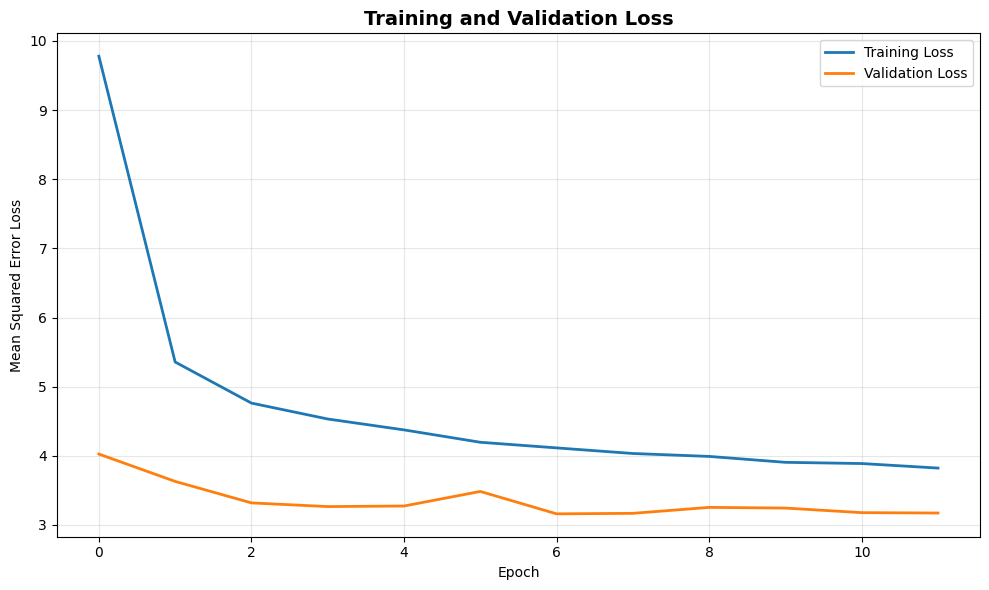


Accuracy plot not applicable: this is a regression model.


In [25]:
# Evaluate Model

# ------------------------------------------------------------
# Evaluate on the Test Dataset
# The model returns the test loss (MSE) and Mean Absolute Error (MAE).
# ------------------------------------------------------------
test_loss, test_mae = fnn_model.evaluate(X_test, y_test, verbose=0)

# Generate predicted ratings for additional regression metrics
y_pred = fnn_model.predict(X_test, verbose=0).flatten()

# Calculate evaluation metrics
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_mae_calculated = mean_absolute_error(y_test, y_pred)

# Display model performance on unseen test data
print("Test Dataset Evaluation Metrics")
print("-" * 35)
print(f"Test Loss (MSE):       {test_loss:.4f}")
print(f"Mean Squared Error:    {test_mse:.4f}")
print(f"Root Mean Squared Error: {test_rmse:.4f}")
print(f"Mean Absolute Error:   {test_mae_calculated:.4f}")

# ------------------------------------------------------------
# Plot Training and Validation Loss
# This plot helps identify whether the model is learning effectively
# and whether it may be overfitting.
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.title("Training and Validation Loss", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot Training and Validation Accuracy (If Available)
# Accuracy is generally not used for rating regression, but this code
# displays it if an accuracy metric is added in a future model version.
# ------------------------------------------------------------
if "accuracy" in history.history:
    plt.figure(figsize=(10, 6))
    plt.plot(history.history["accuracy"], label="Training Accuracy", linewidth=2)
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
    plt.title("Training and Validation Accuracy", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nAccuracy plot not applicable: this is a regression model.")

In [26]:
# Save Trained Model (.keras)

# ------------------------------------------------------------
# Save the Trained FNN Model
# The .keras format preserves the model architecture, weights,
# and training configuration for later Streamlit integration.
# ------------------------------------------------------------
fnn_model.save("book_recommender.keras")
print("✓ Trained model saved as: book_recommender.keras")

# ------------------------------------------------------------
# Save All Feature Encoders
# These encoders ensure incoming Streamlit user/book inputs are
# transformed exactly as they were during model training.
# ------------------------------------------------------------
joblib.dump(encoders, "feature_encoders.pkl")
print("✓ Feature encoders saved as: feature_encoders.pkl")

# ------------------------------------------------------------
# Save the Feature Scaler
# The scaler ensures deployment inputs use the same feature scale
# as the neural network's training data.
# ------------------------------------------------------------
joblib.dump(scaler, "feature_scaler.pkl")
print("✓ Feature scaler saved as: feature_scaler.pkl")

# ------------------------------------------------------------
# Save the Expected Feature Order
# Streamlit must provide features in this exact order for prediction.
# ------------------------------------------------------------
joblib.dump(feature_columns, "feature_columns.pkl")
print("✓ Feature column order saved as: feature_columns.pkl")

print("\nDeployment preparation complete.")
print("The model artifacts are ready for Streamlit integration.")

✓ Trained model saved as: book_recommender.keras
✓ Feature encoders saved as: feature_encoders.pkl
✓ Feature scaler saved as: feature_scaler.pkl
✓ Feature column order saved as: feature_columns.pkl

Deployment preparation complete.
The model artifacts are ready for Streamlit integration.
